In [1]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [2]:
from lightsim2grid import LightSimBackend
import grid2op as gp

In [3]:
backend = LightSimBackend()
env = gp.make('l2rpn_neurips_2020_track1_small', backend=backend)

In [4]:
env.parameters.HARD_OVERFLOW_THRESHOLD

2.0

In [7]:
env.reset()

In [8]:
act = env.action_space({
    'redispatch': [
        (0, 100)
    ]
})
print(act)

This action will:
	 - NOT change anything to the injections
	 - Redispatch gen_33_16 of 100.0
	 - NOT force any line status
	 - NOT switch any line status
	 - NOT switch anything in the topology
	 - NOT force any particular bus configuration


In [9]:
env.step(act)

(<grid2op.Space.GridObjects.CompleteObservation_l2rpn_neurips_2020_track1_small at 0x7fb1a95e5828>,
 -10.0,
 False,
 {'disc_lines': array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False]),
  'is_illegal': False,
  'is_ambiguous': True,
  'is_dispatching_illegal': False,
  'is_illegal_reco': False,
  'opponent_attack_line': None,
  'opponent_attack_sub': None,
  'opponent_attack_duration': 0,
  'exception': [Grid2OpException AmbiguousAction InvalidRedispatching InvalidRedispatching('Some redispatching amount are above the maximum ramp up',)],
  'rewards': {}})

In [12]:
env.get_obs().actual_dispatch

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.], dtype=float32)

In [15]:
env.gen_max_ramp_down

array([ 1.4,  0. ,  1.4, 10.4,  1.4,  0. ,  0. ,  0. ,  0. ,  0. ,  2.8,
        0. ,  0. ,  2.8,  0. ,  0. ,  4.3,  0. ,  0. ,  2.8,  8.5,  9.9],
      dtype=float32)

In [5]:
from grid2op.Agent import BaseAgent

In [151]:
def bus_id(sub_id, bus_num):
    return sub_id * 2 + bus_num - 1

def get_excess(obs):
    n_bus = obs.n_sub * 2
    excess = zeros(n_bus)
    # Generators
    for gen_id in range(obs.n_gen):
        st = obs.state_of(gen_id=gen_id)
        excess[bus_id(st['sub_id'], st['bus'])] += st['p']
    # Loads
    for load_id in range(obs.n_load):
        st = obs.state_of(load_id=load_id)
        excess[bus_id(st['sub_id'], st['bus'])] -= st['p']
    return excess

def can_be_reconnected(obs):
     return where(~obs.line_status & (obs.time_before_cooldown_line == 0))[0]


In [167]:
from scipy import optimize

class RedispAgent(BaseAgent):
    def __init__(
        self, 
        action_space, 
        n_sub,
        n_gen,
        n_load,
#         gen_redispatchable,
#         gen_marginal_costs,
        gen_max_ramp_up,
        gen_max_ramp_down,
        gen_pmax,
    ):
        super().__init__(action_space)
        
        self.n_sub = n_sub
        self.n_bus = 2 * n_sub
        self.n_gen = n_gen
        self.n_load = n_load
#         self.gen_redispatchable = gen_redispatchable
        self.gen_max_ramp_up = gen_max_ramp_up
        self.gen_max_ramp_down = gen_max_ramp_down
        self.gen_pmax = gen_pmax
    
    def act(self, observation, reward=0, done=False):
        exc = get_excess(observation)
        # Decision variables are:
        #   - The imbalances at each bus y_i. Each has two inequality constraints (to implement absolute values)
        #   - The redispatch of each generators x_j. Each has simple bounds.
        dim = self.n_bus + self.n_gen
        c = zeros(dim)
        c[:self.n_bus] = 1
        A_ub = zeros((2 * self.n_bus, dim))
        b_ub = zeros(2 * self.n_bus)
        # No simple bounds for the y_i
        bounds = [(None, None)] * self.n_bus

        for i in range(self.n_bus):
            A_ub[2 * i, i] = -1
            b_ub[2 * i] = -exc[i]
            
            A_ub[2 * i + 1, i] = -1
            b_ub[2 * i + 1] = exc[i]
        for j in range(self.n_gen):
            st = observation.state_of(gen_id=j)
            bu = bus_id(st['sub_id'], st['bus'])
            # Per-generator limits:
            #  - Absolute limits: 0 ≤ prod_p[j] + x_j ≤ gen_pmax[j]
            #  - Ramp up/down limits: -max_ramp_down[j] ≤ x_j ≤ max_ramp_up[j]
            lb = max(-obs.prod_p[j], -self.gen_max_ramp_down[j])
            ub = min(self.gen_pmax[j] - obs.prod_p[j], self.gen_max_ramp_up[j])
            bounds.append((lb, ub))
            # Suppose generator j is attached to bus i.
            # To implement y_i := |excess_i + sum_{j: gen j is attached to bus i} x_j|
            # We use two inequalities:
            # y_i ≥ excess_i + sum_j x_j
            # y_i ≥ -(excess_i + sum_j x_j)
            A_ub[2 * bu, self.n_sub + j] = 1
            A_ub[2 * bu + 1, self.n_sub + j] = -1
        # Redispatch has to sum to zero
        A_eq = zeros((1, dim))
        A_eq[0, self.n_bus:] = 1
        b_eq = zeros(1)
        res = optimize.linprog(c, A_ub, b_ub, A_eq, b_eq, bounds=bounds)
        # return c, A_ub, b_ub, A_eq, b_eq, bounds, res

        ac_dict = {}
        lines_to_reconnect = can_be_reconnected(observation)
        if len(lines_to_reconnect) > 0:
            # Reconnect the first line
            # TODO perhaps simulate to find the "best" line?
            ac_dict.update({
                'set_line_status': [(lines_to_reconnect[0], 1)],
            })
        if not res.success:
            print(res)
        else:
            ac_dict.update({
                'redispatch': [(i, redisp) for i, redisp in enumerate(res.x[self.n_bus:]) if redisp != 0]
            })
        return self.action_space(ac_dict)

In [168]:
agent = RedispAgent(
    env.action_space,
    env.n_sub,
    env.n_gen,
    env.n_load,
    env.gen_max_ramp_up,
    env.gen_max_ramp_down,
    env.gen_pmax,
)

In [104]:
obs = env.get_obs()
c, A_ub, b_ub, A_eq, b_eq, bounds, res = agent.act(obs)

In [62]:
exc = get_excess(obs)
exc

array([ -11.5100002 ,    0.        ,  -34.19999981,    0.        ,
        -15.        ,    0.        ,  -14.89999962,    0.        ,
          0.        ,    0.        ,  109.97000122,    0.        ,
        -13.19999981,    0.        ,   15.30000019,    0.        ,
        -17.29999924,    0.        ,  117.10000038,    0.        ,
         -8.        ,    0.        ,   -7.19999981,    0.        ,
        -25.        ,    0.        ,  -12.80000019,    0.        ,
        -15.5       ,    0.        ,   -9.69999981,    0.        ,
         -6.79999924,    0.        ,   -7.9000001 ,    0.        ,
         -7.5999999 ,    0.        ,   -7.69999981,    0.        ,
         -9.60000038,    0.        ,  -53.29999924,    0.        ,
        -27.60000038,    0.        ,  -41.29999924,    0.        ,
         -5.5       ,    0.        ,   -5.5999999 ,    0.        ,
       -115.69999695,    0.        ,  -33.29999924,    0.        ,
          0.        ,    0.        ,  -15.10000038,    0.     

In [108]:
res

     con: array([1.50923146e-06])
     fun: 1041.0798702077116
 message: 'Optimization terminated successfully.'
     nit: 8
   slack: array([ 2.30200023e+01,  1.89343375e-06,  1.89343375e-06,  1.89343375e-06,
        1.66143604e+01, -1.13755974e-06,  1.89343375e-06,  1.89343375e-06,
        3.00000019e+01,  1.89343375e-06,  1.89343375e-06,  1.89343375e-06,
        2.98000011e+01,  1.89343375e-06,  1.89343375e-06,  1.89343375e-06,
        1.89343375e-06,  1.89343375e-06,  1.89343375e-06,  1.89343375e-06,
        1.89343375e-06,  2.19940004e+02,  1.89343375e-06,  1.89343375e-06,
        2.64000015e+01,  1.89343375e-06,  1.89343375e-06,  1.89343375e-06,
       -1.08110424e-07,  3.06000021e+01,  1.89343375e-06,  1.89343375e-06,
        3.46000004e+01,  1.89343375e-06,  1.89343375e-06,  1.89343375e-06,
       -1.24516821e-05,  2.49599992e+02,  1.89343375e-06,  1.89343375e-06,
        1.60000019e+01,  1.89343375e-06,  1.89343375e-06,  1.89343375e-06,
        1.44000015e+01,  1.89343375e-06,

In [107]:
y, x = res.x[:72], res.x[72:]

In [99]:
env.n_gen

22

In [112]:
ac = env.action_space({
    'redispatch': [(i, redisp) for i, redisp in enumerate(x) if redisp != 0]
})
print(ac)

This action will:
	 - NOT change anything to the injections
	 - Redispatch gen_33_16 of 0.6625323295593262
	 - Redispatch gen_41_18 of 0.6625323295593262
	 - Redispatch gen_41_19 of -4.668663024902344
	 - Redispatch gen_45_20 of 0.6625323295593262
	 - Redispatch gen_54_26 of 1.2927407026290894
	 - Redispatch gen_55_29 of 1.2927407026290894
	 - Redispatch gen_60_32 of 1.930266261100769
	 - Redispatch gen_64_35 of -1.0777138471603394
	 - Redispatch gen_65_36 of 3.4754183292388916
	 - Redispatch gen_68_37 of -4.232387542724609
	 - NOT force any line status
	 - NOT switch any line status
	 - NOT switch anything in the topology
	 - NOT force any particular bus configuration


In [113]:
exc

array([ -11.5100002 ,    0.        ,  -34.19999981,    0.        ,
        -15.        ,    0.        ,  -14.89999962,    0.        ,
          0.        ,    0.        ,  109.97000122,    0.        ,
        -13.19999981,    0.        ,   15.30000019,    0.        ,
        -17.29999924,    0.        ,  117.10000038,    0.        ,
         -8.        ,    0.        ,   -7.19999981,    0.        ,
        -25.        ,    0.        ,  -12.80000019,    0.        ,
        -15.5       ,    0.        ,   -9.69999981,    0.        ,
         -6.79999924,    0.        ,   -7.9000001 ,    0.        ,
         -7.5999999 ,    0.        ,   -7.69999981,    0.        ,
         -9.60000038,    0.        ,  -53.29999924,    0.        ,
        -27.60000038,    0.        ,  -41.29999924,    0.        ,
         -5.5       ,    0.        ,   -5.5999999 ,    0.        ,
       -115.69999695,    0.        ,  -33.29999924,    0.        ,
          0.        ,    0.        ,  -15.10000038,    0.     

In [117]:
sum(abs(exc))

1111.179832905531

In [114]:
env.step(ac)

(<grid2op.Space.GridObjects.CompleteObservation_l2rpn_neurips_2020_track1_small at 0x7fb1a59953c8>,
 938.84393,
 False,
 {'disc_lines': array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False]),
  'is_illegal': False,
  'is_ambiguous': False,
  'is_dispatching_illegal': False,
  'is_illegal_reco': False,
  'opponent_attack_line': None,
  'opponent_attack_sub': None,
  'opponent_attack_duration': 0,
  'exception': [],
  'rewards': {}})

In [116]:
exc1 = get_excess(env.get_obs())
exc1

array([ -10.6700002 ,    0.        ,  -32.06734306,    0.        ,
        -14.60000038,    0.        ,  -14.69999981,    0.        ,
          0.        ,    0.        ,  112.48999786,    0.        ,
        -13.        ,    0.        ,   15.20000076,    0.        ,
        -17.20000076,    0.        ,  113.3942048 ,    0.        ,
         -7.9000001 ,    0.        ,   -7.0999999 ,    0.        ,
        -24.79999924,    0.        ,  -12.03734332,    0.        ,
        -15.5       ,    0.        ,   -9.69999981,    0.        ,
         -6.89999962,    0.        ,   -7.5999999 ,    0.        ,
         -7.5999999 ,    0.        ,   -7.80000019,    0.        ,
         -9.39999962,    0.        ,  -53.59999847,    0.        ,
        -26.10680056,    0.        ,  -39.4068017 ,    0.        ,
         -5.4000001 ,    0.        ,   -5.69999981,    0.        ,
       -116.80000305,    0.        ,  -32.79999924,    0.        ,
          1.92894852,    0.        ,  -16.00000191,    0.     

In [118]:
sum(abs(exc1))

1090.4358335137367

In [121]:
median(obs.rho)

0.33697224

In [122]:
obs1 = env.get_obs()

In [124]:
median(obs1.rho)

0.33689454

In [125]:
obs1.actual_dispatch

array([ 0.6626565,  0.       ,  0.6626565, -4.668462 ,  0.6626565,
        0.       ,  0.       ,  0.       ,  0.       ,  0.       ,
        1.2931991,  0.       ,  0.       ,  1.2931991,  0.       ,
        0.       ,  1.9289485,  0.       ,  0.       , -1.0766559,
        3.4747128, -4.2329116], dtype=float32)

In [126]:
x

array([ 0.66253233, -0.        ,  0.66253233, -4.66866301,  0.66253233,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
        1.29274066, -0.        , -0.        ,  1.29274066, -0.        ,
       -0.        ,  1.93026621, -0.        , -0.        , -1.07771386,
        3.47541828, -4.23238742])

In [255]:
from grid2op.Agent import RecoPowerlineAgent
reco_agent = RecoPowerlineAgent(env.action_space)

In [264]:
env.set_id(2)
env.seed(123)
obs = env.reset()
obss = [obs]
infos = []
# reco_obss = [obs]
# reco_infos = []
dur, acc_rew = 0, 0
done = False
while not done:
# while not done and dur < 1141 - 3:
    ac = agent.act(obs)
#     ac = reco_agent.act(obs, 0)
    obs, rew, done, info = env.step(ac)
    acc_rew += rew
    dur += 1
#     reco_obss.append(obs)
#     reco_infos.append(info)
    obss.append(obs)
    infos.append(info)

In [219]:
ac1 = env.action_space({
    'set_bus': {
        'lines_or_id': [
            (32, 2), 
            (34, 2),
        ],
    },
})
print(ac)

This action will:
	 - NOT change anything to the injections
	 - NOT perform any redispatching action
	 - NOT force any line status
	 - NOT switch any line status
	 - NOT switch anything in the topology
	 - Set the bus of the following element:
	 	 - assign bus 2 to line (origin) 32 [on substation 23]
	 	 - assign bus 2 to line (origin) 34 [on substation 23]


In [224]:
while not done:
    ac = agent.act(obs)
    obs, rew, done, info = env.step(ac)
    acc_rew += rew
    dur += 1
    obss.append(obs)
    infos.append(info)

In [265]:
dur

1141

In [230]:
where(info['disc_lines'])

(array([25, 27, 28, 40, 41]),)

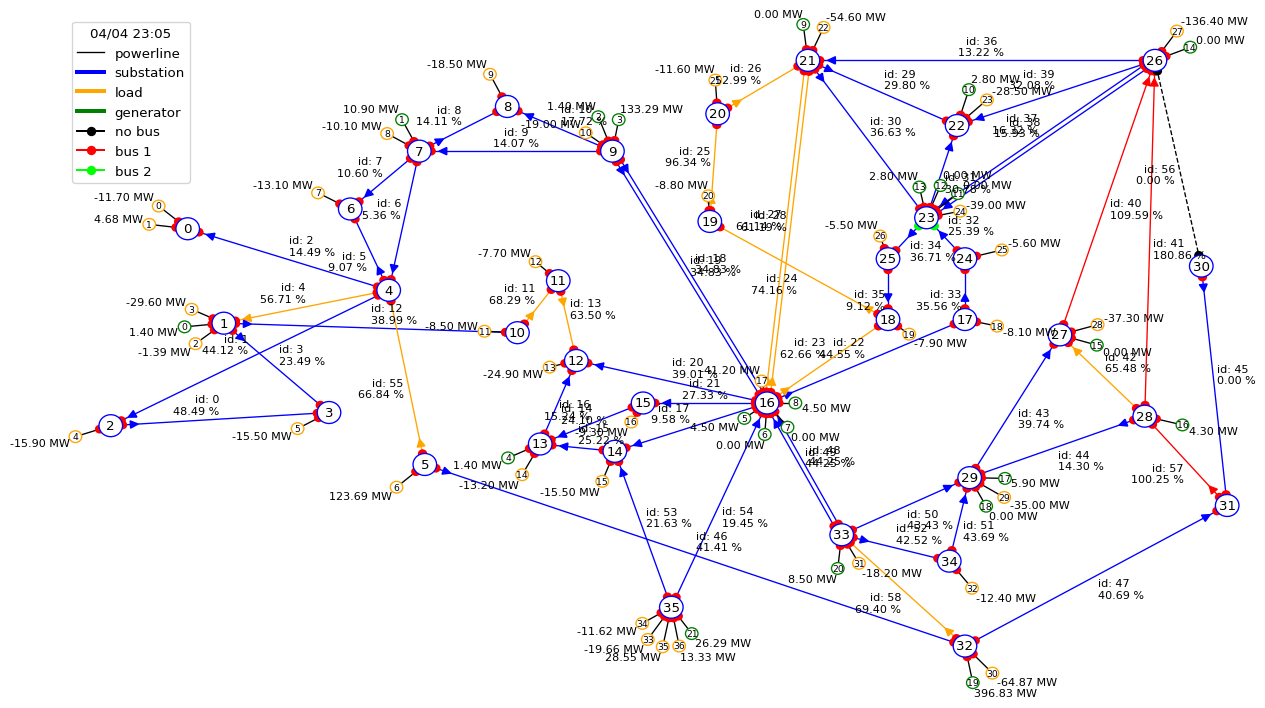

In [231]:
_ = plot_helper.plot_obs(obs)

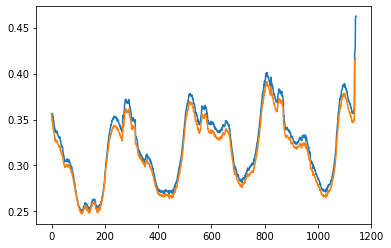

In [267]:
plot([ob.rho.mean() for ob in reco_obss])
plot([ob.rho.mean() for ob in obss])

Text(0, 0.5, 'rho')

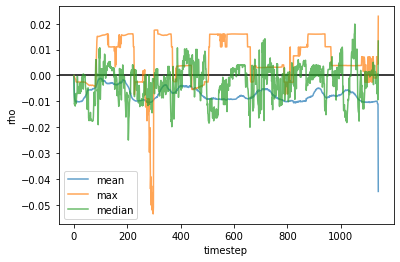

In [298]:
# Reco any + redispatch vs. Reco
axhline(0, c='black')
plot([ob.rho.mean() - reco_ob.rho.mean() for ob, reco_ob in zip(obss, reco_obss)], label='mean', alpha=0.7)
plot([ob.rho.max() - reco_ob.rho.max() for ob, reco_ob in zip(obss, reco_obss)], label='max', alpha=0.7)
plot([median(ob.rho) - median(reco_ob.rho) for ob, reco_ob in zip(obss, reco_obss)], label='median', alpha=0.7)
legend()
xlabel('timestep')
ylabel('rho')

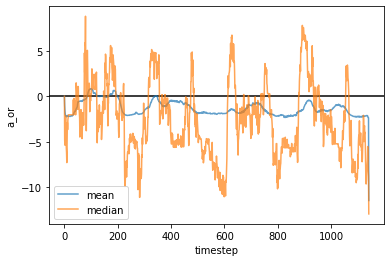

In [300]:
# Reco any + redispatch vs. Reco
axhline(0, c='black')
plot([ob.a_or.mean() - reco_ob.a_or.mean() for ob, reco_ob in zip(obss, reco_obss)], label='mean', alpha=0.7)
# plot([ob.a_or.max() - reco_ob.a_or.max() for ob, reco_ob in zip(obss, reco_obss)], label='max', alpha=0.7)
plot([median(ob.a_or) - median(reco_ob.a_or) for ob, reco_ob in zip(obss, reco_obss)], label='median', alpha=0.7)
ylabel('a_or')
xlabel('timestep')
legend()

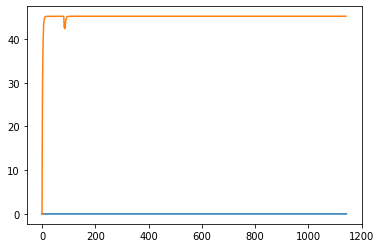

In [266]:
plot([abs(ob.actual_dispatch).sum() for ob in reco_obss])
plot([abs(ob.actual_dispatch).sum() for ob in obss])

In [284]:
redisp = stack([ob.actual_dispatch for ob in obss])

In [286]:
redisp.shape

(1142, 22)

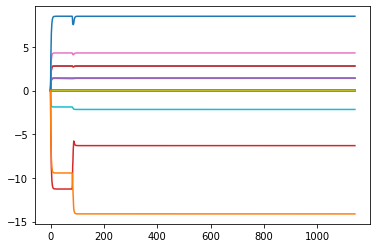

In [288]:
_ = plot(redisp)

In [196]:
[ob.rho[41] for ob in obss][-10:]

[0.6468436,
 0.64512795,
 0.64464,
 0.6579088,
 0.65437007,
 0.67335325,
 1.6343544,
 1.66152,
 1.6749799,
 1.6749799]

In [201]:
[ob.rho[40] for ob in obss[-10:]]

[0.36766,
 0.36707386,
 0.36623034,
 0.37492895,
 0.3725776,
 0.38347134,
 0.98565555,
 1.0019007,
 1.0102916,
 1.0102916]

In [202]:
env.parameters.NB_TIMESTEP_OVERFLOW_ALLOWED

3

In [211]:
infos[-1]

{'disc_lines': array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False]),
 'is_illegal': False,
 'is_ambiguous': False,
 'is_dispatching_illegal': False,
 'is_illegal_reco': False,
 'opponent_attack_line': array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, 

In [220]:
obs, _, _, info = env.step(ac1)

In [222]:
obs.state_of(line_id=32)

{'origin': {'p': -7.9627013,
  'q': 0.52715963,
  'v': 146.11923,
  'a': 31.531313,
  'bus': 2,
  'sub_id': 23},
 'extremity': {'p': 7.983185,
  'q': -3.1848915,
  'v': 146.24208,
  'a': 33.93244,
  'bus': 1,
  'sub_id': 24},
 'maintenance': {'next': -1, 'duration_next': 0},
 'cooldown_time': 0}

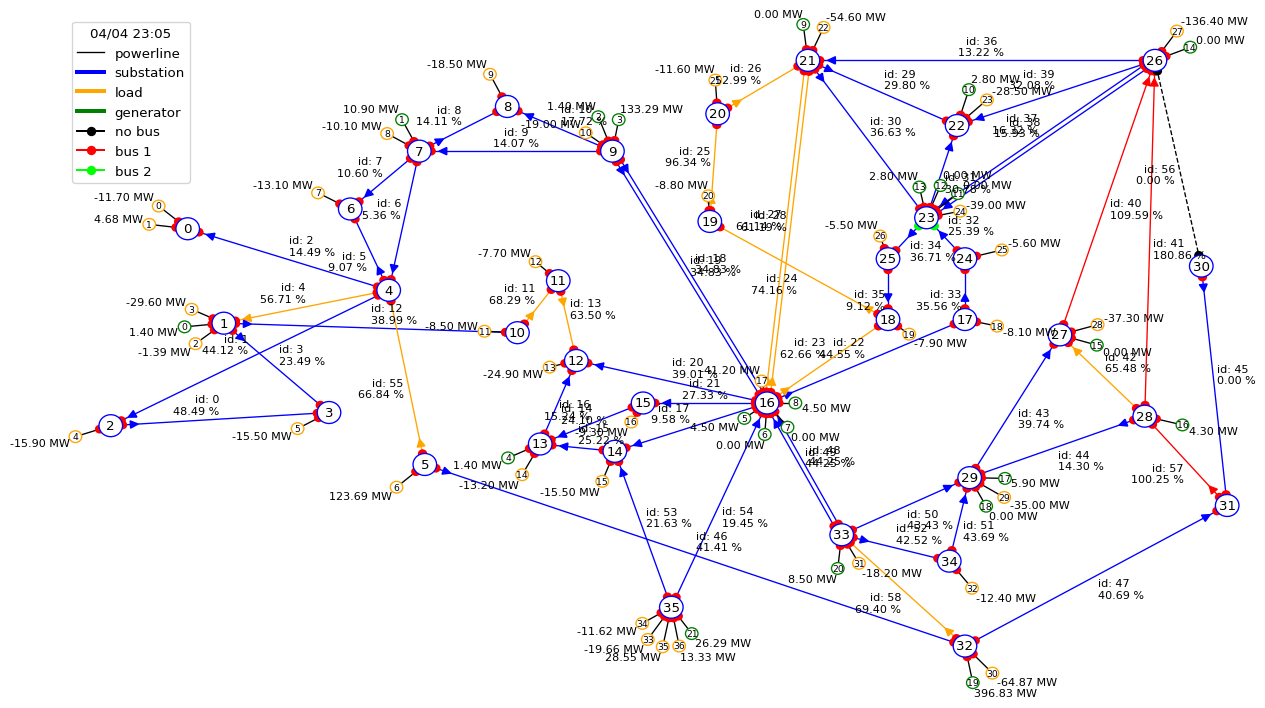

In [223]:
_ = plot_helper.plot_obs(obs)

In [197]:
from grid2op.PlotGrid import PlotMatplot
plot_helper = PlotMatplot(env.observation_space, line_id=True)

In [188]:
obs.actual_dispatch

array([  1.4008892,   0.       ,   1.4008892,  -6.3098354,   1.4008892,
         0.       ,   0.       ,   0.       ,   0.       ,   0.       ,
         2.8009179,   0.       ,   0.       ,   2.8009179,   0.       ,
         0.       ,   4.3004427,   0.       ,   0.       ,  -2.1688726,
         8.500045 , -14.12628  ], dtype=float32)

In [185]:
get_excess(obs)

array([  -7.01999998,    0.        ,  -29.58911121,    0.        ,
        -15.89999962,    0.        ,  -15.5       ,    0.        ,
          0.        ,    0.        ,  123.69000244,    0.        ,
        -13.10000038,    0.        ,    0.79999924,    0.        ,
        -18.5       ,    0.        ,  115.69106555,    0.        ,
         -8.5       ,    0.        ,   -7.69999981,    0.        ,
        -24.89999962,    0.        ,  -11.79911065,    0.        ,
        -15.5       ,    0.        ,   -9.30000019,    0.        ,
        -32.20000076,    0.        ,   -8.10000038,    0.        ,
         -7.9000001 ,    0.        ,   -8.80000019,    0.        ,
        -11.60000038,    0.        ,  -54.59999847,    0.        ,
        -25.69908214,    0.        ,  -36.19908214,    0.        ,
         -5.5999999 ,    0.        ,   -5.5       ,    0.        ,
       -136.3999939 ,    0.        ,  -37.29999924,    0.        ,
          4.3004427 ,    0.        ,  -29.0999999 ,    0.     

In [184]:
env.gen_pmax[0]

50.0

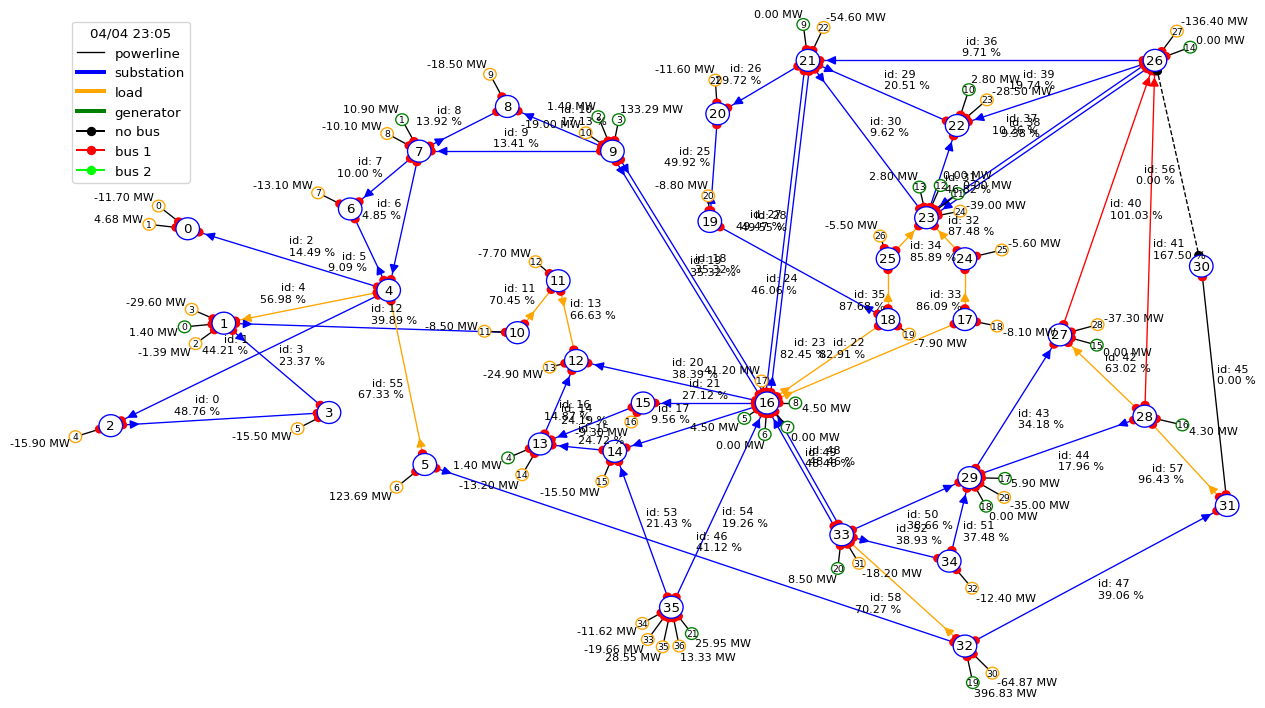

In [198]:
_ = plot_helper.plot_obs(obs)

In [191]:
where(info['disc_lines'])

(array([32, 34, 35, 40, 41]),)

In [178]:
where(obs.rho == 0)

(array([45, 56]),)

In [175]:
obs.line_status

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True])

In [174]:
obs.time_before_cooldown_line

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0, 45,  0,  0], dtype=int32)

In [140]:
env.chronics_handler.get_name()

'Scenario_april_002'

In [173]:
can_be_reconnected(obs)

array([], dtype=int64)

In [250]:
def april_eval(agent, seed=253):
    # Performance is measured in rewards and durations
    acc_rews, durs = [], []

    env = gp.make('l2rpn_neurips_2020_track1_small', backend=backend)
    env.set_id(0)
    env.seed(seed)
    for i in range(48):
        obs = env.reset()
        print(i, env.chronics_handler.get_name(), end=' ')
        done, acc_rew, dur, rew = False, 0, 0, 0
        while not done:
            ac = agent.act(obs, rew)
            obs, rew, done, _ = env.step(ac)
            acc_rew += rew
            dur += 1
        print(acc_rew, dur)
        acc_rews.append(acc_rew)
        durs.append(dur)
    return acc_rews, durs

def summary_and_plot(acc_rewards, durations, draw_plots=True):
    print(
        'mean rewards:', 
        mean(acc_rewards), 
        'mean duration:', 
        mean(durations), 
        'median rewards:', 
        median(acc_rewards), 
        'median duration:',
        median(durations),
    )
    if draw_plots:
        _, (ax1, ax2) = subplots(2, 1, sharex='all')
        ax1.bar(range(48), sorted(acc_rewards, reverse=True))
        ax2.bar(range(48), sorted(durations, reverse=True))
        xlabel('rank')
    return mean(acc_rewards), mean(durations), median(acc_rewards), median(durations)

In [233]:
acc_rews, durs = april_eval(agent)

0 Scenario_april_000 957745.8449707031 1022
1 Scenario_april_001 1137203.996459961 1227
2 Scenario_april_002 1923838.6745605469 2063
3 Scenario_april_003 1283454.3892822266 1405
4 Scenario_april_004 370071.53259277344 369
5 Scenario_april_005 959315.8668823242 1031
6 Scenario_april_006 230931.71350097656 236
7 Scenario_april_007 507787.25939941406 534
8 Scenario_april_008 885941.6671142578 966
9 Scenario_april_009 719677.03125 785
10 Scenario_april_010 149481.14611816406 158
11 Scenario_april_011 1453881.2607421875 1561
12 Scenario_april_012 932102.3029785156 976
13 Scenario_april_013 350275.96575927734 354
14 Scenario_april_014 1349769.445678711 1488
15 Scenario_april_015 343362.82080078125 346
16 Scenario_april_016 1441318.0549316406 1551
17 Scenario_april_017 821255.2578125 842
18 Scenario_april_018 2260849.472229004 2421
19 Scenario_april_019 648123.5964355469 693
20 Scenario_april_020 339754.544921875 358
21 Scenario_april_021 200780.36389160156 203
22 Scenario_april_022 524234.37

(1041131.3546536764, 718493.4850158691)

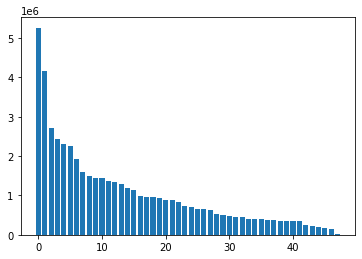

In [234]:
bar(range(48), sorted(acc_rews, reverse=True))
mean(acc_rews), median(acc_rews)

(1125.7083333333333, 771.0)

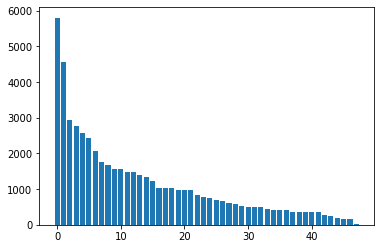

In [236]:
bar(range(48), sorted(durs, reverse=True))
mean(durs), median(durs)

mean rewards: 1041131.3546536764 mean duration: 1125.7083333333333 median rewards: 718493.4850158691 median duration: 771.0


(1041131.3546536764, 1125.7083333333333, 718493.4850158691, 771.0)

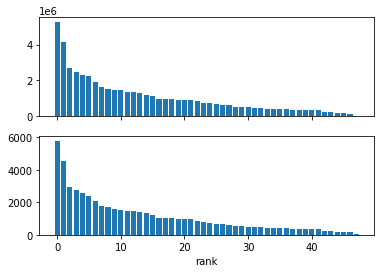

In [253]:
summary_and_plot(acc_rews, durs)

In [312]:
env2 = gp.make('l2rpn_neurips_2020_track1_small', backend=backend)
env2.reset()

In [305]:
ac_dis_1 = env2.action_space({
    'set_line_status': [
        (56, -1),
    ],
})
ac_dis_2 = env2.action_space({
    'set_line_status': [
        (45, -1),
    ],
})
print(ac_dis_1)
print(ac_dis_2)

This action will:
	 - NOT change anything to the injections
	 - NOT perform any redispatching action
	 - force disconnection of 1 powerlines ([56])
	 - NOT switch any line status
	 - NOT switch anything in the topology
	 - NOT force any particular bus configuration
This action will:
	 - NOT change anything to the injections
	 - NOT perform any redispatching action
	 - force disconnection of 1 powerlines ([45])
	 - NOT switch any line status
	 - NOT switch anything in the topology
	 - NOT force any particular bus configuration


In [316]:
env2.step(ac_dis_2)

(<grid2op.Space.GridObjects.CompleteObservation_l2rpn_neurips_2020_track1_small at 0x7fb196920a90>,
 -10.0,
 True,
 {'disc_lines': array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False]),
  'is_illegal': False,
  'is_ambiguous': False,
  'is_dispatching_illegal': False,
  'is_illegal_reco': False,
  'opponent_attack_line': None,
  'opponent_attack_sub': None,
  'opponent_attack_duration': 0,
  'exception': [Grid2OpException DivergingPowerFlow DivergingPowerFlow('GAME OVER: Powerflow has diverged during computation or a load has been disconnected or a generator has been disco

In [328]:
env2.backend.check_kirchoff?

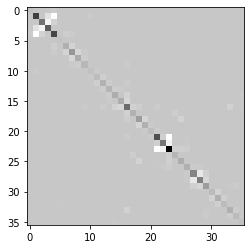

In [327]:
imshow(env.backend._grid.get_Ybus().todense().real, cmap='Greys')